## Цель работы

Знакомство элементами технологии создания баз знаний интеллектуальных систем.

### Задачи

- Освоение способа сохранения и загрузки обученных моделей машинного обучения;
- Разработка интерфейса доступа к сохраненным моделям;
- Организация произвольных запросов с использованием разработанного интерфейса.

## Основная часть
---

### Подключение пакетов

Перед началом работы нужно убедиться, что необходимые для работы пакеты установлены в системе.

In [1]:
import sys
print(f"Версия Python - {sys.version}")
print(f"Путь к интерпретатору Python - {sys.executable}")

Версия Python - 3.10.11 | packaged by conda-forge | (main, May 10 2023, 18:58:44) [GCC 11.3.0]
Путь к интерпретатору Python - /home/kavalord/miniconda3/envs/ml_labs/bin/python


In [2]:
import pandas as pd
import numpy  as np

import sklearn
from sklearn import linear_model
from sklearn import ensemble
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from matplotlib import pyplot as plt
from matplotlib import cm
import seaborn as sns

import tensorflow as tf
from IPython.display import clear_output
import plotly.graph_objects as go

### Объявление функций 

In [3]:
def stats(y_test, y_pred):
    '''
    Вычисление и вывод метрик: MAE, RMSE, R2. Используются функции из библиотеки sklearn
    На основе сравнения проверочных и вычисленных.
    :param y_test: - проверочные значения целевой переменной
    :param y_pred: - вычисленные значения целевой переменной
    '''
    mae  = metrics.mean_absolute_error(y_test, y_pred)
    mse  = metrics.mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = metrics.r2_score(y_test, y_pred)
    print ("MAE : {:>9,.3f} (средняя абсолютная ошибка)".format(mae))
    print ("MSE : {:>9,.6f} (среднеквадратичная ошибка)".format(mse))
    print ("RMSE: {:>9,.6f} (кв. корень из среднеквадратичной ошибки)".format(rmse))
    print ("R2  : {:>9,.3f} (коэфф. детерминации)".format(r2))
    return {"MAE":mae, "MSE":mse, "RMSE":rmse, "R2":r2}

In [4]:
def plot_difference(y_test, y_pred) -> None:
    '''
    Функция построения графиков
    :param y_test: - проверочные значения целевой переменной
    :param y_pred: - вычисленные значения целевой переменной
    '''
    plt.figure(figsize=(12,6))
    
    plt.subplot(121)
    plt.scatter(y_test, y_pred,  alpha=0.1, color = "#17becf")
    plt.axline((0, 0), slope=1, color='black', linestyle='--', linewidth=3, alpha=0.7,)
    range_test, range_pred = np.max(y_test)- np.min(y_test) , np.max(y_pred)- np.min(y_pred)
    if range_test/range_pred <4 and range_test/range_pred > 0.25:
        plt.gca().set_aspect('equal')
        axmin, axmax = np.min([y_test, y_pred]), np.max([y_test, y_pred])
        plt.xlim([axmin, axmax]); plt.ylim([axmin, axmax]);
    plt.title('Диаграмма рассеяния вычисленных значений');
    plt.xlabel('Проверочное Y')
    plt.ylabel('Вычисленное Y')
    plt.grid(True)

    plt.subplot(122) # 1 row, 2 column, 2 index on grid
    plt.scatter(y_test, (y_test - y_pred)**2,  alpha=0.1, color = "#17becf")
    plt.title('Диаграмма рассеяния квадрата абсолютной ошибки')
    plt.xlabel('Проверочное Y')
    plt.ylabel('Квадрат абсолютной ошибки')
    plt.grid(True)

### Загрузка подготовленных данных

Структура csv-файла:
- Ячейки разделены ";"
- Дробная часть помечена "."

In [6]:
dataset_file = "../datasets/dataset_prepared.csv"
df = pd.read_csv(
    dataset_file,
    sep=';',
    decimal='.',
    header=0
)

df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,OcPrx_<1H OCEAN,OcPrx_INLAND,OcPrx_ISLAND,OcPrx_NEAR BAY,OcPrx_NEAR OCEAN
0,352100,7.2574,52,1467.0,190,496,177,37.85,-122.24,8259.085109,554610.7171,733525.6829,64867.28983,18811.48745,0,0,0,1,0
1,342200,3.8462,52,1627.0,280,565,259,37.85,-122.25,7768.086571,555194.2661,734095.2907,65287.13841,18031.04757,0,0,0,1,0
2,269700,4.0368,52,919.0,213,413,193,37.85,-122.25,7768.086571,555194.2661,734095.2907,65287.13841,18031.04757,0,0,0,1,0
3,299200,3.6591,52,2535.0,489,1094,514,37.84,-122.25,6843.020847,554364.4069,733249.8086,64315.99174,17538.20997,0,0,0,1,0
4,241400,3.1200,52,3104.0,687,1157,647,37.84,-122.25,6843.020847,554364.4069,733249.8086,64315.99174,17538.20997,0,0,0,1,0


Выясним размеры датасета

In [7]:
num_rows, num_cols = df.shape
print(f"Размеры набора данных: {num_rows} строк и {num_cols} столбцов\n")
df.info()

Размеры набора данных: 16361 строк и 19 столбцов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16361 entries, 0 to 16360
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        16361 non-null  int64  
 1   Median_Income             16361 non-null  float64
 2   Median_Age                16361 non-null  int64  
 3   Tot_Rooms                 16361 non-null  float64
 4   Tot_Bedrooms              16361 non-null  int64  
 5   Population                16361 non-null  int64  
 6   Households                16361 non-null  int64  
 7   Latitude                  16361 non-null  float64
 8   Longitude                 16361 non-null  float64
 9   Distance_to_coast         16361 non-null  float64
 10  Distance_to_LA            16361 non-null  float64
 11  Distance_to_SanDiego      16361 non-null  float64
 12  Distance_to_SanJose       16361 non-null  float64
 13  Distance_to

Целевой признак - Median Income: Медианный доход на семью в квартале[10тыс.$].

Коэфф. корреляции Пирсона позволит выбрать независимые переменные.

In [8]:
target=['Median_Income']
corr_coeffs = df.corr(method='pearson')
corr_coeffs[target[0]].abs().sort_values(ascending=False)

Median_Income               1.000000
Median_House_Value          0.603495
Tot_Rooms                   0.237004
Median_Age                  0.184637
OcPrx_INLAND                0.156272
Distance_to_coast           0.155083
OcPrx_<1H OCEAN             0.136902
Tot_Bedrooms                0.079887
Distance_to_SanJose         0.066688
Population                  0.060554
Distance_to_SanFrancisco    0.050521
Households                  0.046777
Longitude                   0.033349
OcPrx_NEAR BAY              0.026521
OcPrx_NEAR OCEAN            0.026242
Latitude                    0.019742
Distance_to_LA              0.011811
OcPrx_ISLAND                0.011041
Distance_to_SanDiego        0.006869
Name: Median_Income, dtype: float64

В качестве независимых переменных выберем признаки с высоким абс. значением коэфф. корреляции, но при этом как можно более не связанные между собой. Кандидаты:
- *Median_House_Value* - Медианная цена дома в квартале [$]
- *Distance_to_coast*- расстояние до ближайшей точки побережья [м] (или *OcPrx_INLAND*)
- *Tot_Rooms* - Общее количество комнат в квартале
- *Median_Age* - Медианный возраст дома в квартале; меньше = новее [лет]

Дополнительно к ним добавим признак *Population*, в связке с которым при построении линейной модели проявилось свойство синергии - оценка R^2 была самой большой `R^2 = 0.465`

In [9]:
features = ['Median_House_Value', 'Distance_to_coast', 'Tot_Rooms',  'Median_Age', 'Population']

Уберем все прочие признаки

In [10]:
df = df[target + features]
df.head()

,Median_Income,Median_House_Value,Distance_to_coast,Tot_Rooms,Median_Age,Population
0,7.2574,352100,8259.085109,1467.0,52,496
1,3.8462,342200,7768.086571,1627.0,52,565
2,4.0368,269700,7768.086571,919.0,52,413
3,3.6591,299200,6843.020847,2535.0,52,1094
4,3.1200,241400,6843.020847,3104.0,52,1157


In [11]:
dfX=df[features]
dfX.head()

,Median_House_Value,Distance_to_coast,Tot_Rooms,Median_Age,Population
0,352100,8259.085109,1467.0,52,496
1,342200,7768.086571,1627.0,52,565
2,269700,7768.086571,919.0,52,413
3,299200,6843.020847,2535.0,52,1094
4,241400,6843.020847,3104.0,52,1157


In [12]:
dfY=df[target]
dfY.head()

,Median_Income
0,7.2574
1,3.8462
2,4.0368
3,3.6591
4,3.1200


### Нормализация данных

Воспользуемся маштабированием через скейлер min-max. По [умолчанию](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#:~:text=feature_rangetuple%20(min%2C%20max)%2C%20default%3D(0%2C%201)) скейлер выдает нормированный диапазон.

In [13]:
scalerNormForX  = MinMaxScaler()
dfXNorm  = pd.DataFrame (
  data    = scalerNormForX.fit_transform(dfX),
  columns = dfX.columns,
  index   = dfX.index
)
dfXNorm.head()

,Median_House_Value,Distance_to_coast,Tot_Rooms,Median_Age,Population
0,0.725415,0.067896,0.243825,1.0,0.056472
1,0.704111,0.063800,0.270527,1.0,0.064376
2,0.548097,0.063800,0.152370,1.0,0.046964
3,0.611578,0.056082,0.422063,1.0,0.124971
4,0.487197,0.056082,0.517023,1.0,0.132188


In [14]:
scalerNormForY  = MinMaxScaler()
dfYNorm  = pd.DataFrame (
  data    = scalerNormForY.fit_transform(dfY),
  columns = dfY.columns,
  index   = dfY.index
)
dfYNorm.head()

,Median_Income
0,0.900988
1,0.446167
2,0.471580
3,0.421221
4,0.349342


Построим гистограммы распределения целевого признака

In [15]:
def histograms(df, dfStd, feature_name):
    '''
    Построение гистограмм распределения признака до и после стандартизации
    '''
    plt.figure(figsize=(10,5))

    plt.subplot(121)
    plt.title('Распределение исходных значений')
    plt.xlabel(feature_name)
    plt.ylabel('Количество записей')
    plt.hist(df[feature_name])

    plt.subplot(122)
    plt.title('Распределение нормализованных значений')
    plt.xlabel(feature_name)
    plt.ylabel('Количество записей')
    plt.hist(dfStd[feature_name])

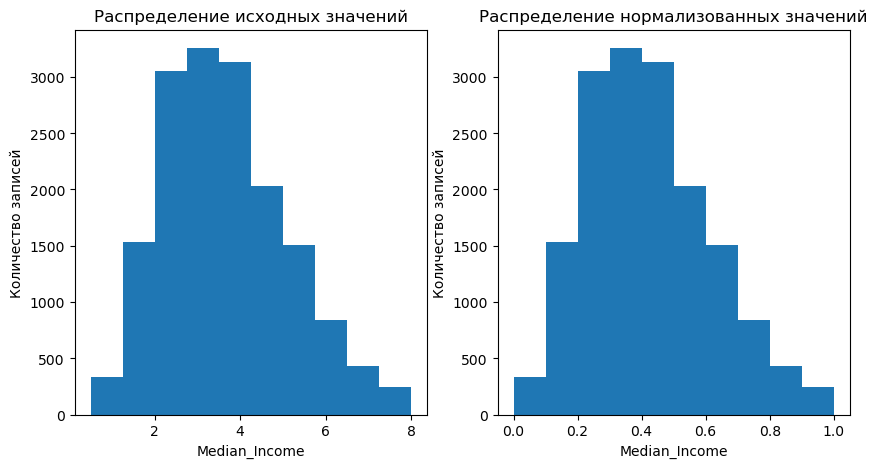

In [16]:
histograms(dfY, dfYNorm, target[0])

То же сделаем для независимых признаков

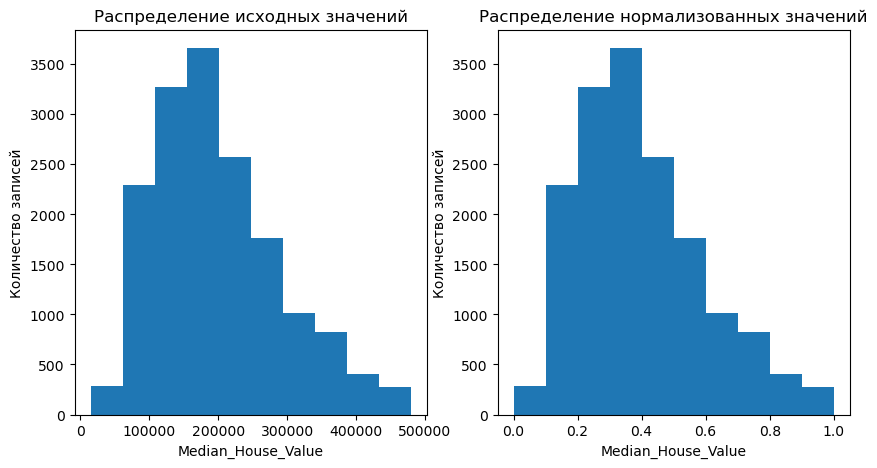

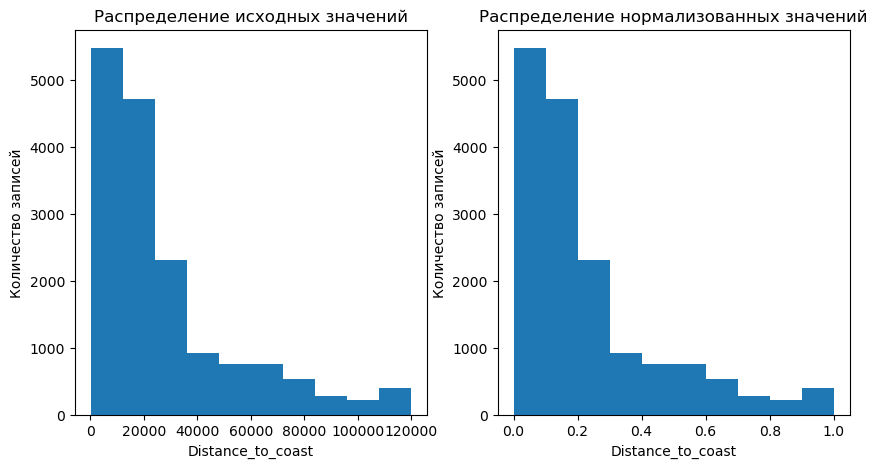

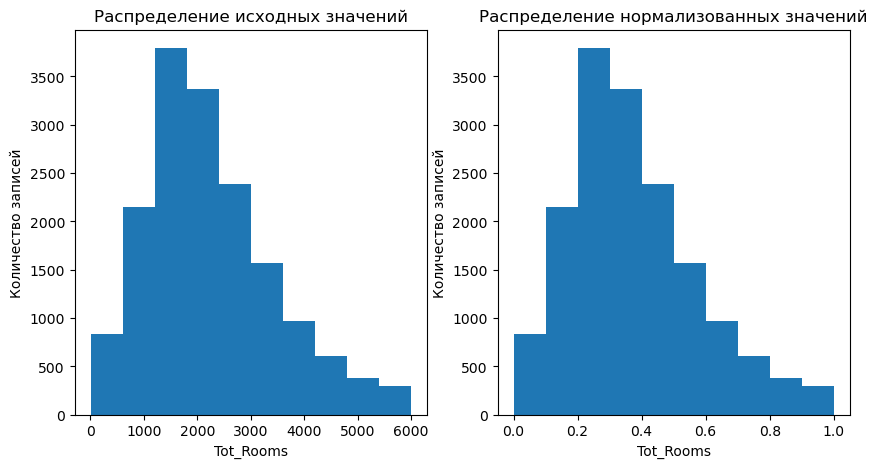

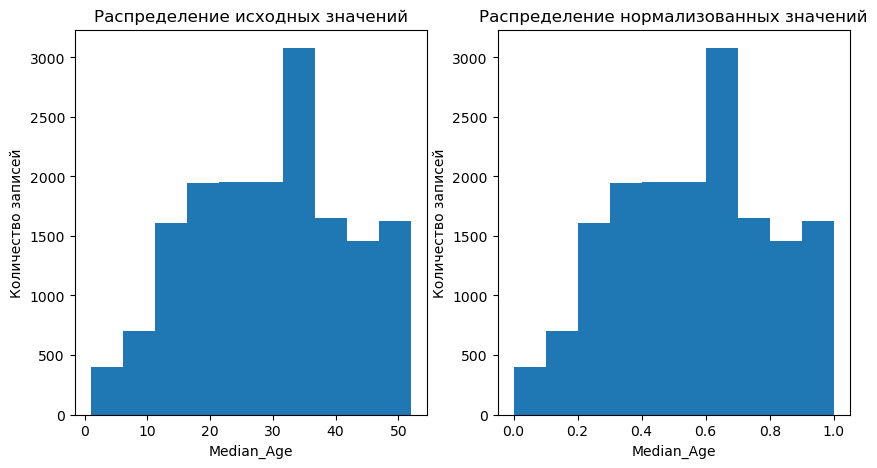

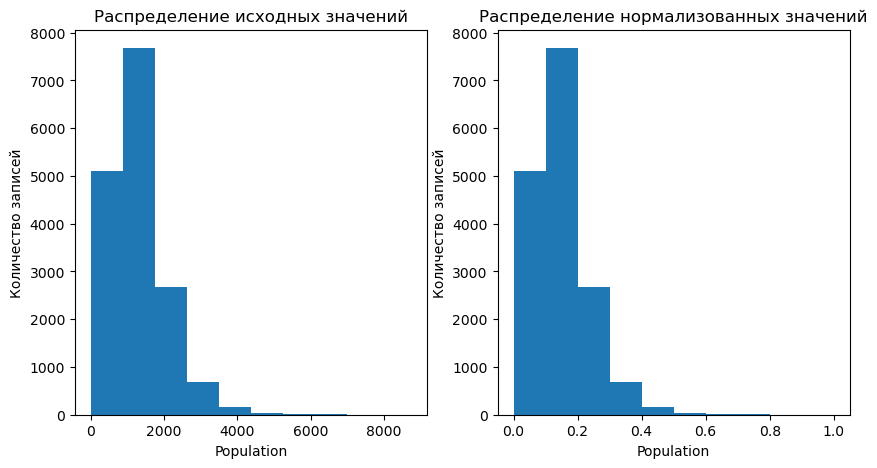

In [17]:
for feat in features:
    histograms(dfX, dfXNorm, feat)

### Формирование тренировочной и проверочной выборок

Зададим сид генератора случайных чисел. А также долю тестовой выборки.

In [18]:
random_state = 42
test_size = 0.2

Разделим выборку на текстовую и тренировочную части.

In [19]:
xTrain, xTest, yTrain, yTest = train_test_split(
    dfX,
    dfY,
    test_size=test_size,
    random_state=random_state,
    shuffle=True
)

yTrain = yTrain[target[0]]
yTest  = yTest[target[0]]

In [20]:
xNormTrain , xNormTest, yNormTrain, yNormTest = train_test_split(
    dfXNorm,
    dfYNorm,
    test_size=test_size,
    random_state=random_state,
    shuffle=True
)

yNormTrain = yNormTrain[target[0]]
yNormTest  = yNormTest[target[0]]

### Линейная регрессия

In [21]:
linearModel = linear_model.LinearRegression()
linearModel.fit(xTrain, yTrain)
yPred = linearModel.predict(xTest)
linearStats = stats(yTest, yPred)

MAE :     0.835 (средняя абсолютная ошибка)
MSE :  1.114879 (среднеквадратичная ошибка)
RMSE:  1.055878 (кв. корень из среднеквадратичной ошибки)
R2  :     0.465 (коэфф. детерминации)


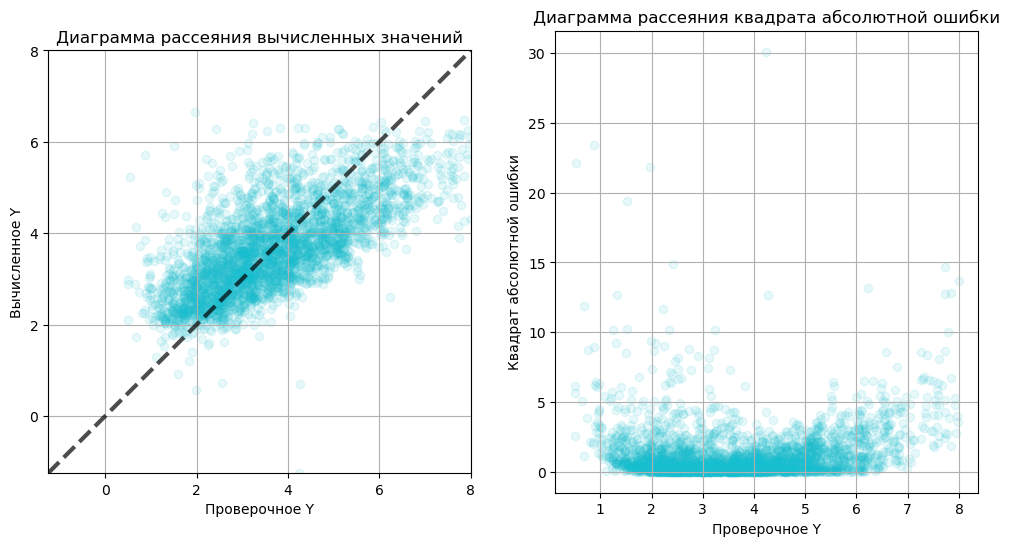

In [22]:
plot_difference(yTest, yPred)

### Нейронка

In [49]:
def initNewModel(size=5):
    global totalHistoryLossTrain
    totalHistoryLossTrain=[]
    global totalHistoryLossTest
    totalHistoryLossTest=[]

    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Input(shape=(size,)))

    model.add(tf.keras.layers.Dense(units=1000, activation=tf.keras.activations.relu))
    model.add(tf.keras.layers.Dense(units=500, activation=tf.keras.activations.relu))
    model.add(tf.keras.layers.Dense(units=200, activation=tf.keras.activations.relu))
    model.add(tf.keras.layers.Dense(units=10, activation=tf.keras.activations.relu))

    model.add(tf.keras.layers.Dense(units=1,  activation=None))

    fLoss=tf.keras.losses.MeanSquaredError()
    fOptimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
    fMetricList  = [tf.keras.losses.MeanSquaredError()]
    model.compile(
        loss      =fLoss,
        optimizer =fOptimizer,
        metrics   = fMetricList
    )
    return model

In [60]:
neuralModel = initNewModel()
epochForTrain = 150
batchSize = 256

In [61]:
history = neuralModel.fit(
    xNormTrain,
    yNormTrain,
    validation_data=(xNormTest,yNormTest),
    epochs=epochForTrain,
    batch_size=batchSize
)

totalHistoryLossTrain.extend(history.history['loss'])
if 'val_loss' in history.history.keys():
    totalHistoryLossTest.extend(history.history['val_loss'])

Epoch 1/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0729 - mean_squared_error: 0.0720 - val_loss: 0.0203 - val_mean_squared_error: 0.0202
Epoch 2/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0203 - mean_squared_error: 0.0204 - val_loss: 0.0216 - val_mean_squared_error: 0.0216
Epoch 3/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0197 - mean_squared_error: 0.0195 - val_loss: 0.0190 - val_mean_squared_error: 0.0190
Epoch 4/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0191 - mean_squared_error: 0.0191 - val_loss: 0.0194 - val_mean_squared_error: 0.0194
Epoch 5/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0192 - mean_squared_error: 0.0191 - val_loss: 0.0181 - val_mean_squared_error: 0.0181
Epoch 6/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0186 - mean_squared_error: 0.0186 - val_loss: 0.0199 - val_mean_squared_error: 0.0199
Epoch 7/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0184 - mean_squared_error: 0.0185 - val_loss: 0.01

(0.015, 0.02)

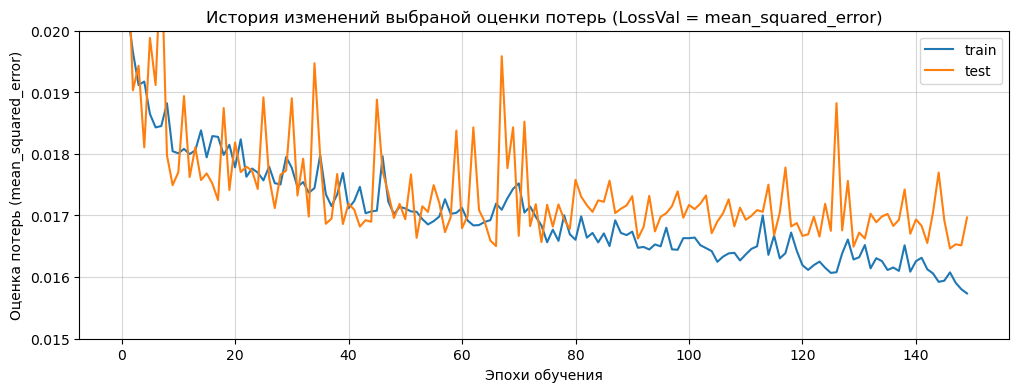

In [62]:
plt.figure(figsize=(12,4))
plt.plot(totalHistoryLossTrain, label='train', color = '#1f77b4')
if 'val_loss' in history.history.keys():
    plt.plot(totalHistoryLossTest, label='test', color = '#ff7f0e')
plt.title("История изменений выбраной оценки потерь (LossVal = mean_squared_error)")
plt.ylabel("Оценка потерь (mean_squared_error)"); plt.xlabel("Эпохи обучения")
plt.legend()
plt.grid(True, alpha=0.5)  # Сетка
plt.ylim((0.015,0.02))

In [114]:
yNormPred = neuralModel.predict(xNormTest).reshape(1, -1)[0] # потому что столбе
yNormPredDf = pd.DataFrame({target[0] : yNormPred})
yNormTestDf = pd.DataFrame({target[0] : yNormTest})
yRescaledPred = scalerNormForY.inverse_transform(yNormPredDf)
yRescaledTest = scalerNormForY.inverse_transform(yNormTestDf)
neuralStats = stats(yRescaledTest, yRescaledPred)

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE :     0.769 (средняя абсолютная ошибка)
MSE :  0.954405 (среднеквадратичная ошибка)
RMSE:  0.976936 (кв. корень из среднеквадратичной ошибки)
R2  :     0.542 (коэфф. детерминации)


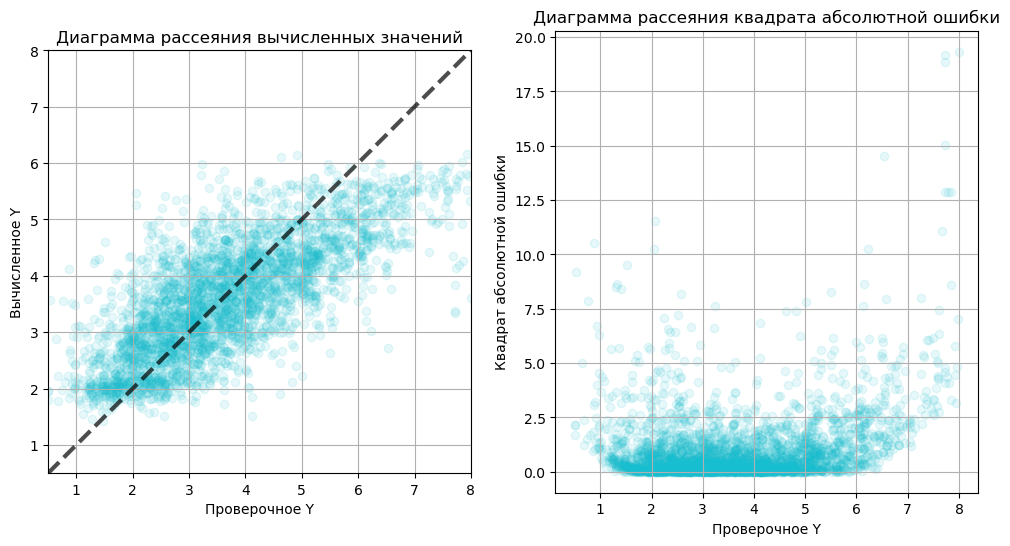

In [115]:
plot_difference(yRescaledTest, yRescaledPred)

### Ансамбль

In [65]:
maxDepth=15
maxFeatures=0.4
ntrees=500

In [66]:
rfModel = ensemble.RandomForestRegressor(
    max_depth=maxDepth,
    max_features=maxFeatures,
    n_estimators=ntrees,
    random_state=random_state
)
rfModel.fit(xTrain, yTrain)


,n_estimators,500
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
yPredRf = rfModel.predict(xTest)
rfStats = stats(yTest, yPredRf)

MAE :     0.756 (средняя абсолютная ошибка)
MSE :  0.930566 (среднеквадратичная ошибка)
RMSE:  0.964658 (кв. корень из среднеквадратичной ошибки)
R2  :     0.554 (коэфф. детерминации)


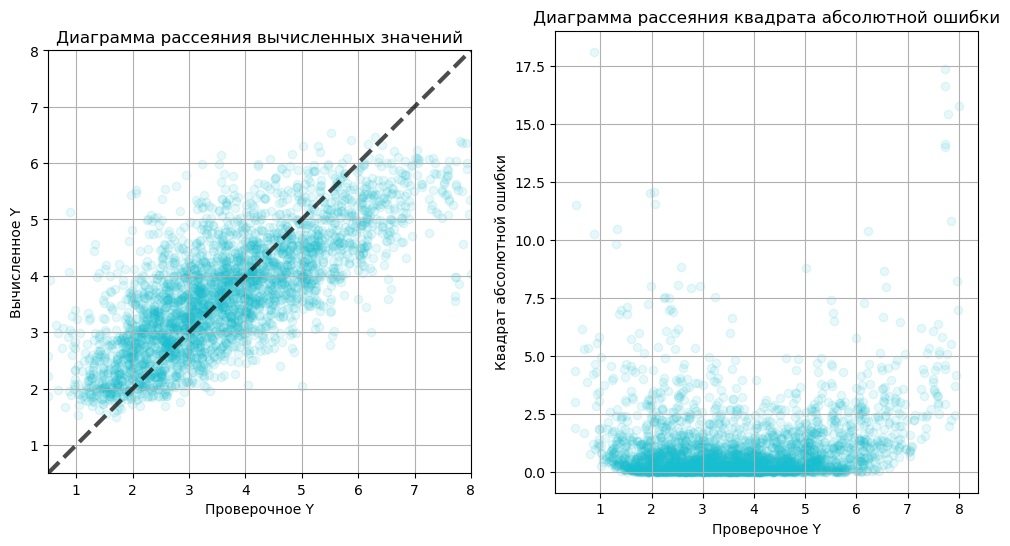

In [68]:
plot_difference(yTest, yPredRf)

## Сохранение

In [69]:
linearMeta = {
    'type' : type(linearModel).__name__,
    'mustScale' : False,
    'inFeatures' : features,
    'outFeatures' : target,
    'R2' : linearStats["R2"],
    'RMSE' : linearStats["RMSE"],
    'MAE' : linearStats["MAE"]
}
linearMeta

{'type': 'LinearRegression',
 'mustScale': False,
 'inFeatures': ['Median_House_Value',
  'Distance_to_coast',
  'Tot_Rooms',
  'Median_Age',
  'Population'],
 'outFeatures': ['Median_Income'],
 'R2': 0.46544966022974676,
 'RMSE': 1.0558781009146339,
 'MAE': 0.8347963205574996}

In [70]:
neuralMeta = {
    'type' : type(neuralModel).__name__,
    'mustScale' : True,
    'inFeatures' : features,
    'outFeatures' : target,
    'R2' : neuralStats["R2"],
    'RMSE' : neuralStats["RMSE"],
    'MAE' : neuralStats["MAE"]
}
neuralMeta

{'type': 'Sequential',
 'mustScale': True,
 'inFeatures': ['Median_House_Value',
  'Distance_to_coast',
  'Tot_Rooms',
  'Median_Age',
  'Population'],
 'outFeatures': ['Median_Income'],
 'R2': 0.5423920865408015,
 'RMSE': 1.4768362859854842,
 'MAE': 1.2687931829082768}

In [71]:
rfMeta = {
    'type' : type(rfModel).__name__,
    'mustScale' : False,
    'inFeatures' : features,
    'outFeatures' : target,
    'R2' : rfStats["R2"],
    'RMSE' : rfStats["RMSE"],
    'MAE' : rfStats["MAE"]
}
rfMeta

{'type': 'RandomForestRegressor',
 'mustScale': False,
 'inFeatures': ['Median_House_Value',
  'Distance_to_coast',
  'Tot_Rooms',
  'Median_Age',
  'Population'],
 'outFeatures': ['Median_Income'],
 'R2': 0.5538219431628617,
 'RMSE': 0.964658469218097,
 'MAE': 0.756388381668634}

In [72]:
import os
import json
import pickle

In [73]:
outDir = "out"
linearMetaPath = outDir + "/linearMeta.json"
neuralMetaPath = outDir + "/neuralMeta.json"
rfMetaPath = outDir + "/rfMeta.json"

scalerNormForXPath = outDir + "/scalerNormForX.pkl"
scalerNormForYPath = outDir + "/scalerNormForY.pkl"

linearModelPath = outDir + "/linearModel.pkl"
neuralModelPath = outDir + "/neuralModel.keras"
rfModelPath = outDir + "/rfModel.pkl"

In [74]:
os.makedirs(outDir, exist_ok=True)

In [75]:
json.dump(linearMeta, open(linearMetaPath, 'w'))
json.dump(neuralMeta, open(neuralMetaPath, 'w'))
json.dump(rfMeta, open(rfMetaPath, 'w'))

In [76]:
pickle.dump(scalerNormForX, open(scalerNormForXPath, 'wb'))
pickle.dump(scalerNormForY, open(scalerNormForYPath, 'wb'))

In [77]:
pickle.dump(linearModel, open(linearModelPath, 'wb'))
neuralModel.save(neuralModelPath)
pickle.dump(rfModel, open(rfModelPath, 'wb'))

### Загрузка обратно

In [78]:
linearMetaRestored = json.load(open(linearMetaPath, 'r'))
neuralMetaRestored = json.load(open(neuralMetaPath, 'r'))
rfMetaMetaRestored = json.load(open(rfMetaPath, 'r'))

In [79]:
scalerNormForXRestored = pickle.load(open(scalerNormForXPath, 'rb'))
scalerNormForYRestored = pickle.load(open(scalerNormForYPath, 'rb'))

In [80]:
linearModelRestored = pickle.load(open(linearModelPath, 'rb'))
neuralModelRestored = tf.keras.models.load_model(neuralModelPath)
rfModelRestored = pickle.load(open(rfModelPath, 'rb'))

### Опрос объектов

In [81]:
def printScaler(scaler):
    dmax = scaler.data_max_
    dmin = scaler.data_min_
    for i in range(np.size(dmax)):
        print(f"[{dmin[i]}, {dmax[i]}]")

In [82]:
printScaler(scalerNormForXRestored)

[14999.0, 479700.0]
[120.6764466, 119986.2118]
[6.0, 5998.0]
[1.0, 52.0]
[3.0, 8733.0]


In [83]:
printScaler(scalerNormForYRestored)

[0.4999, 8.0]


In [84]:
dataVector = {
    'Median_House_Value' : [12353],
    'Distance_to_coast' : [65],
    'Tot_Rooms' : [2],
    'Median_Age' : [45],
    'Population' : [0]
}
dfV = pd.DataFrame(dataVector)
dfV.head()

,Median_House_Value,Distance_to_coast,Tot_Rooms,Median_Age,Population
0,12353,65,2,45,0


In [85]:
trV = scalerNormForXRestored.transform(dfV)
print(trV)

[[-5.69398387e-03 -4.64490868e-04 -6.67556742e-04  8.62745098e-01
  -3.43642612e-04]]


In [86]:
invTrV = scalerNormForXRestored.inverse_transform(dfV)
print(invTrV)

[[5.74046645e+09 7.79138047e+06 1.19900000e+04 2.29600000e+03
  3.00000000e+00]]


In [87]:
scalerNormForXRestored.fit(dfV)
printScaler(scalerNormForXRestored)

[12353.0, 12353.0]
[65.0, 65.0]
[2.0, 2.0]
[45.0, 45.0]
[0.0, 0.0]


In [88]:
rfModelRestored.predict(dfV)

array([2.47971295])

In [116]:
xTest

,Median_House_Value,Distance_to_coast,Tot_Rooms,Median_Age,Population
2858,283300,21100.540820,5305.0,37,3895
11208,87900,7616.288910,939.0,25,1003
7731,201200,28523.190710,2716.0,16,898
4948,315400,39404.352180,1835.0,52,777
733,195200,6539.238325,2630.0,27,1414
...,...,...,...,...,...
763,182700,7036.580566,786.0,36,463
6835,324000,2129.147925,2685.0,28,1243
8000,266400,29732.546540,4380.0,5,1913
13242,222800,34589.310630,2610.0,19,1290


In [117]:
yTest

2858     2.0672
11208    1.7500
7731     2.2536
4948     3.7159
733      2.8203
          ...  
763      3.9338
6835     4.1190
8000     6.7274
13242    4.1298
12828    3.6148
Name: Median_Income, Length: 3273, dtype: float64